# Comparing and converting schemas

A schema is rarely the last word. It gets rewritten as the model changes, and it gets
*reused*. [rudof](https://rudof-project.github.io/rudof/) has one operation for each of those jobs:
`compare_schemas` says how two schemas differ, and `convert_schemas` turns one into
something else.

## Preliminaries

In [1]:
%pip install -q "pyrudof>=0.3.22"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyrudof import ReaderMode, Rudof

rudof = Rudof()

## Comparing

Schemas change. A property is renamed, a datatype is tightened, a constraint is added... and
the interesting question for everyone downstream is *what exactly changed*. Diffing the
schema files as text answers that badly: reordering, reformatting and prefix changes all
show up as differences, while a genuine change hidden behind a renamed prefix does not.

rudof compares two schemas **structurally**, at the level of shapes and properties, which
ignores everything that is only notation.

### Two versions of a model

Here are two takes on the same `:Person` shape. Version 1 records an age and a weight;
version 2 has dropped both, added a birth date, and uses the prefix `ex:` where version 1 used the default prefix `:`. Both prefixes expand to `http://example.org/`, so the two schemas share far more than a textual diff would suggest.

In [3]:
schema1 = """
PREFIX :    <http://example.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

:Person {
   :name     xsd:string  ;
   :age      xsd:integer ;
   :weight   xsd:float   ;
   :worksFor .
}
"""

In [4]:
schema2 = """
PREFIX ex:  <http://example.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

ex:Person {
   ex:name      xsd:string ;
   ex:birthDate xsd:date   ;
   ex:worksFor  .
}
"""

### Running the comparison

`compare_schemas` takes the two schemas and, for each one, how to read it. The positional
arguments come in pairs, one per schema:

| Arguments | Meaning |
| --- | --- |
| `schema1`, `schema2` | the schemas themselves, as content or as paths |
| `mode1`, `mode2` | the schema language: `"shex"`, `"shacl"`, `"dctap"` |
| `format1`, `format2` | the concrete syntax: `"shexc"`, `"shexj"`, `"turtle"`, `"csv"`, … |
| `base1`, `base2` | base IRI for resolving relative IRIs, or `None` |
| `label1`, `label2` | **which shape to compare**, as a full IRI |
| `reader_mode` | `ReaderMode.Lax` or `ReaderMode.Strict` for the RDF reader |

The labels are not optional in practice: a schema usually declares several shapes, and the
comparison is between *one shape and one shape*. Note that they are given as full IRIs,
not as the qualified names used in the schema text.

In [5]:
result = rudof.compare_schemas(
    schema1, schema2,
    "shex", "shex",
    "shexc", "shexc",
    None, None,
    "http://example.org/Person", "http://example.org/Person",
    ReaderMode.Lax,
)

print(result)

Shapes Comparison:
 Equal properties:
  - http://example.org/name: 
  - descr1:   - value: http://example.org/name
  - datatype: http://www.w3.org/2001/XMLSchema#string

  - descr2:   - value: http://example.org/name
  - datatype: http://www.w3.org/2001/XMLSchema#string


  - http://example.org/worksFor: 
  - descr1:   - value: http://example.org/worksFor
  - datatype: _

  - descr2:   - value: http://example.org/worksFor
  - datatype: _


 Properties in shape 1 that are not in shape 2:
  - http://example.org/age: 
  - descr:   - value: http://example.org/age
  - datatype: http://www.w3.org/2001/XMLSchema#integer


  - http://example.org/weight: 
  - descr:   - value: http://example.org/weight
  - datatype: http://www.w3.org/2001/XMLSchema#float


 Properties in shape 2 that are not in shape 1:
  - http://example.org/birthDate: 
  - descr:   - value: http://example.org/birthDate
  - datatype: http://www.w3.org/2001/XMLSchema#date






The report is in three parts, and each answers a different question:

* **Equal properties**: what a consumer of version 1 can keep relying on. `:name` and
  `:worksFor` survived the rename unchanged, because the comparison works on expanded IRIs.
* **Properties in shape 1 that are not in shape 2**: what will *disappear*: `:age` and
  `:weight`. Code that reads them needs to change.
* **Properties in shape 2 that are not in shape 1**: what is *new*: `:birthDate`.
  Producers need to start emitting it.

A property that exists in both but with a different datatype shows up in both of the last
two sections, with its datatype spelled out in each, so a tightened constraint is visible
rather than silently "equal".

### Comparing a schema with itself

The degenerate case is worth seeing, because it is what a passing check looks like in CI:
every property lands in *Equal properties* and the other two sections are empty.

In [6]:
result = rudof.compare_schemas(
    schema1, schema1,
    "shex", "shex",
    "shexc", "shexc",
    None, None,
    "http://example.org/Person", "http://example.org/Person",
    ReaderMode.Lax,
)

print(result)

Shapes Comparison:
 Equal properties:
  - http://example.org/age: 
  - descr1:   - value: http://example.org/age
  - datatype: http://www.w3.org/2001/XMLSchema#integer

  - descr2:   - value: http://example.org/age
  - datatype: http://www.w3.org/2001/XMLSchema#integer


  - http://example.org/weight: 
  - descr1:   - value: http://example.org/weight
  - datatype: http://www.w3.org/2001/XMLSchema#float

  - descr2:   - value: http://example.org/weight
  - datatype: http://www.w3.org/2001/XMLSchema#float


  - http://example.org/name: 
  - descr1:   - value: http://example.org/name
  - datatype: http://www.w3.org/2001/XMLSchema#string

  - descr2:   - value: http://example.org/name
  - datatype: http://www.w3.org/2001/XMLSchema#string


  - http://example.org/worksFor: 
  - descr1:   - value: http://example.org/worksFor
  - datatype: _

  - descr2:   - value: http://example.org/worksFor
  - datatype: _






### What can go wrong

The most common error is forgetting the shape labels. Without them rudof has no way to know
which shape you meant, and says so:

In [7]:
from pyrudof import ComparisonError

try:
    rudof.compare_schemas(schema1, schema2, "shex", "shex", "shexc", "shexc")
except ComparisonError as e:
    print(f"{type(e).__name__}: {e}")

ComparisonError: Schema comparison error: Error converting ShEx to CoShaMo for source 'string': No shape label provided (check option to add shape label)


## Converting

`convert_schemas` is rudof's general schema converter. Every call names four things: what
language is coming in, what language should come out, and the concrete syntax of each.

The two `Mode` enums list the languages and the two `Format` enums the syntaxes:

In [8]:
from pyrudof import (
    ConversionFormat,
    ConversionMode,
    ResultConversionFormat,
    ResultConversionMode,
)

print("input modes:   ", [str(m) for m in ConversionMode.all()])
print("output modes:  ", [str(m) for m in ResultConversionMode.all()])
print("input formats: ", [str(f) for f in ConversionFormat.all()])
print("output formats:", [str(f) for f in ResultConversionFormat.all()])

input modes:    ['Shacl', 'ShEx', 'Dctap']
output modes:   ['Sparql', 'ShEx', 'Uml', 'Html', 'Shacl']
input formats:  ['Csv', 'ShExC', 'ShExJ', 'Turtle', 'Xlsx']
output formats: ['Default', 'Internal', 'Json', 'ShExC', 'ShExJ', 'Turtle', 'PlantUML', 'Html', 'Svg', 'Png']


Not every pair of modes is implemented. What the enums list is the ambition; what works
today in the published `pyrudof` is this:

| From ↓ To → | ShEx | SHACL | UML | SPARQL |
| --- | :-: | :-: | :-: | :-: |
| **ShEx** | ✓ | — | ✓ | ✓ |
| **SHACL** | partial | ✓ | — | — |
| **DCTAP** | ✓ | — | ✓ | — |

A cell marked `—` raises `ConversionError`, which is easy to handle. SHACL as an input is
the one to be careful with: it converts only the simplest shapes, and on anything with a
cardinality or a node reference the published version aborts the process rather than
raising. The examples below stay on the paths that work.

### DCTAP to ShEx

This is the conversion that makes [DCTAP](dctap.ipynb) worth using: a table that domain
experts maintain in a spreadsheet becomes a schema that machines validate against.

It needs one thing the table does not say: which IRIs the bare names in it stand for.
`Person` in a `shapeId` column has to become an IRI, and `name` in a `propertyId` column
likewise. That is what the `[tap2shex]` section of a rudof configuration file is for. Without it, rudof falls back to a `http://default/` namespace, and the generated schema is technically correct but useless in practice.

In [9]:
from pathlib import Path
from tempfile import TemporaryDirectory

from pyrudof import RudofConfig

CONFIG_TOML = """
[tap2shex]
base_iri = "http://example.org/"

[tap2shex.prefixmap]
"" = "http://example.org/"
xsd = "http://www.w3.org/2001/XMLSchema#"
rdfs = "http://www.w3.org/2000/01/rdf-schema#"
"""

tmpdir = TemporaryDirectory()
config_path = Path(tmpdir.name) / "config.toml"
config_path.write_text(CONFIG_TOML)

tap = Rudof(RudofConfig.from_path(config_path))

The profile is the one from the [DCTAP chapter](dctap.ipynb):

In [10]:
dctap_str = """shapeId,propertyId,mandatory,repeatable,valueDatatype,valueShape
Person,name,true,false,xsd:string,
,birthdate,false,false,xsd:date,
,worksFor,false,true,,Company
Company,name,true,false,xsd:string,
,employee,false,true,,Person
"""

shex_schema = tap.convert_schemas(
    dctap_str,
    input_mode=ConversionMode.Dctap,
    output_mode=ResultConversionMode.ShEx,
    input_format=ConversionFormat.Csv,
    output_format=ResultConversionFormat.ShExC,
)

print(shex_schema)

prefix : <http://example.org/>
prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#>
prefix xsd: <http://www.w3.org/2001/XMLSchema#>
:Person { :name xsd:string; :birthdate xsd:date ?; :worksFor @:Company * }
:Company { :name xsd:string; :employee @:Person * }



### Using the result

The round trip is the point, so it is worth closing: load the generated schema and validate
real data against it.

In [11]:
tap.read_shex(shex_schema)

tap.read_data("""
prefix :    <http://example.org/>
prefix xsd: <http://www.w3.org/2001/XMLSchema#>

:alice :name      "Alice"                ;
       :birthdate "1970-01-01"^^xsd:date ;
       :worksFor  :acme                  .
:acme  :name      "ACME INC."            .

:bob   :name      23                     .
""")

tap.read_shapemap(":alice@:Person, :acme@:Company, :bob@:Person")
report = tap.validate_shex()

print("conforms:", report.conforms)

conforms: False


`:alice` and `:acme` are fine. `:bob` has a `:name` that is an integer where the profile
said `xsd:string`, so it fails (against a constraint that was written in a spreadsheet
cell).

In [12]:
for entry in report.violations:
    print(f"{entry.node} failed {entry.shape}:")
    print(entry.details)

http://example.org/bob failed http://example.org/Person:
Datatype error on node :bob for property :name: found xsd:integer, expected xsd:string, lexical form "23"^^xsd:integer


### Between syntaxes of one language

`input_mode` and `output_mode` do not have to differ. Keeping both on `ShEx` and changing
only the formats re-serializes a schema: here from the compact syntax people write to the
JSON one tools consume.

In [13]:
shex_source = """
PREFIX :    <http://example.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

:Person {
  :name      xsd:string  ;
  :birthDate xsd:date ?  ;
  :worksFor  @:Company * ;
}

:Company {
  :name xsd:string ;
}
"""

shexj = rudof.convert_schemas(
    shex_source,
    input_mode=ConversionMode.ShEx,
    output_mode=ResultConversionMode.ShEx,
    input_format=ConversionFormat.ShExC,
    output_format=ResultConversionFormat.ShExJ,
)

print(shexj[:420], "...")

{
  "@context": "http://www.w3.org/ns/shex.jsonld",
  "type": "Schema",
  "shapes": [
    {
      "type": "ShapeDecl",
      "id": "http://example.org/Person",
      "abstract": false,
      "shapeExpr": {
        "type": "Shape",
        "expression": {
          "type": "EachOf",
          "expressions": [
            {
              "type": "TripleConstraint",
              "predicate": "http://example.org/name",
 ...


### ShEx to a diagram

`ResultConversionMode.Uml` draws the schema. Asking for `PlantUML` gives the diagram
source, but `Svg` and `Png` make rudof render it too, so a notebook can display the picture
without any diagram tooling installed.

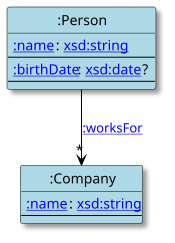

In [14]:
from IPython.display import SVG

svg = rudof.convert_schemas(
    shex_source,
    input_mode=ConversionMode.ShEx,
    output_mode=ResultConversionMode.Uml,
    input_format=ConversionFormat.ShExC,
    output_format=ResultConversionFormat.Svg,
)

SVG(svg)

Each shape is a class, each datatype constraint a field with its cardinality, and each
shape reference an arrow (`:worksFor` points from `:Person` to `:Company` with
multiplicity `*`).

The same works from DCTAP, which is the quickest way to review a profile with whoever
wrote the spreadsheet:

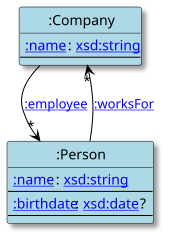

In [15]:
SVG(tap.convert_schemas(
    dctap_str,
    input_mode=ConversionMode.Dctap,
    output_mode=ResultConversionMode.Uml,
    input_format=ConversionFormat.Csv,
    output_format=ResultConversionFormat.Svg,
))

`ResultConversionMode.Html` produces browsable HTML documentation from the same input. It writes
several files rather than returning a string, so it needs an `output_folder` and a
`templates_folder`.

### ShEx to SPARQL

The last output mode is the surprising one: a shape is a description of a neighbourhood, so
it can be turned into a [SPARQL](sparql.ipynb) query that retrieves exactly that
neighbourhood. `shape` picks which one, as a prefixed name.

In [16]:
sparql = rudof.convert_schemas(
    shex_source,
    input_mode=ConversionMode.ShEx,
    output_mode=ResultConversionMode.Sparql,
    input_format=ConversionFormat.ShExC,
    output_format=ResultConversionFormat.Default,
    base="http://example.org/",
    shape=":Person",
)

print(sparql)

http://example.org/
prefix : <http://example.org/>
prefix xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT * WHERE {
 ?this :name ?name .
 ?this :birthDate ?birthDate .
 ?this :worksFor ?worksFor .
}



That is a ready-made query for every `:Person` in a dataset, generated from the shape
rather than written by hand.

Two rough edges to know about. The first line of the output is the base IRI, echoed by the
converter and not part of the query, so strip it before running the text. And `shape` must
be a *prefixed* name: passing the full IRI `http://example.org/Person` fails looking up
`http` as a prefix.

In [17]:
tmpdir.cleanup()

## References
* [rudof documentation](https://rudof-project.github.io/rudof/) - the `compare` and
  `convert` subcommands of the command line tool, which expose the same functionality.